In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print ("Libraries loaded successfully")

Libraries loaded successfully


In [5]:
from google.colab import files
uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index (1).csv


In [6]:
# Load datasets
sentiment = pd.read_csv("../data/fear_greed_index.csv")
trades = pd.read_csv("../data/hyperliquid_trades.csv")
print("Sentiment Dataset Shape:", sentiment.shape)
print("Trades Dataset Shape:", trades.shape)

Sentiment Dataset Shape: (2644, 4)
Trades Dataset Shape: (211224, 16)


In [ ]:
print("Sentiment Data Preview:")
display(sentiment.head())
print("\nTrades Data Preview:")
display(trades.head())

In [14]:
trades ['date'] = pd.to_datetime(trades['Timestamp IST']).dt.date

ValueError: time data "18-03-2025 12:50" doesn't match format "%m-%d-%Y %H:%M", at position 18. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [20]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [8]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [11]:
trades['date'] = pd.to_datetime(
    trades['Timestamp IST'],
    errors='coerce'
).dt.date

In [12]:
trades['date'].isna().sum()

np.int64(131999)

In [15]:
trades['Timestamp IST'].head(10)

,Timestamp IST
0,02-12-2024 22:50
1,02-12-2024 22:50
2,02-12-2024 22:50
3,02-12-2024 22:50
4,02-12-2024 22:50
5,02-12-2024 22:50
6,02-12-2024 22:50
7,02-12-2024 22:50
8,02-12-2024 22:50
9,02-12-2024 22:50


In [18]:
trades['date'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y  %H:%M'
).dt.date

In [19]:
trades['date'].isna().sum()

np.int64(0)

In [21]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [22]:
sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [25]:
sentiment['date'].dtype

dtype('<M8[ns]')

In [24]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [28]:
trades['date'].dtype

dtype('<M8[ns]')

In [27]:
trades['date'] = pd.to_datetime(trades['date'])

In [29]:
merged_data = pd.merge(trades, sentiment, on='date', how='inner')

In [30]:
merged_data.shape

(211218, 20)

In [31]:
merged_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1733117400,80,Extreme Greed


In [32]:
merged_data = merged_data.drop(columns=['timestamp'])

In [33]:
merged_data.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'date', 'value', 'classification'],
      dtype='object')

In [34]:
merged_data['classification'].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


In [35]:
merged_data.groupby('classification')['Closed PnL'].mean()

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


In [36]:
merged_data.groupby('classification')['Closed PnL'].sum()

,Closed PnL
classification,
Extreme Fear,7.391102e+05
Extreme Greed,2.715171e+06
Fear,3.357155e+06
Greed,2.150129e+06
Neutral,1.292921e+06


In [37]:
merged_data.groupby('classification')['Closed PnL'].describe()

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Fear,21400.0,34.537862,1136.056091,-31036.69194,0.0,0.0,5.635032,115287.00000
Extreme Greed,39992.0,67.892861,766.828294,-10259.46800,0.0,0.0,10.028709,44223.45187
Fear,61837.0,54.290400,935.355438,-35681.74723,0.0,0.0,5.590856,135329.09010
Greed,50303.0,42.743559,1116.028390,-117990.10410,0.0,0.0,4.944105,74530.52371
Neutral,37686.0,34.307718,517.122220,-24500.00000,0.0,0.0,3.995795,48504.09555


In [38]:
merged_data.groupby(['classification', 'Side'])['Closed PnL'].mean()


classification  Side
Extreme Fear    BUY      34.114627
                SELL     34.980106
Extreme Greed   BUY      10.498927
                SELL    114.584643
Fear            BUY      63.927104
                SELL     45.049641
Greed           BUY      25.002302
                SELL     59.691091
Neutral         BUY      29.227429
                SELL     39.456408
Name: Closed PnL, dtype: float64

In [39]:
merged_data.groupby(['classification', 'Side']).size()

classification  Side
Extreme Fear    BUY     10935
                SELL    10465
Extreme Greed   BUY     17940
                SELL    22052
Fear            BUY     30270
                SELL    31567
Greed           BUY     24576
                SELL    25727
Neutral         BUY     18969
                SELL    18717
dtype: int64

In [40]:
merged_data['is_profit'] = merged_data['Closed PnL'] > 0
merged_data.groupby(['classification', 'Side'])['is_profit'].mean()

classification  Side
Extreme Fear    BUY     0.201646
                SELL    0.547157
Extreme Greed   BUY     0.311427
                SELL    0.589833
Fear            BUY     0.263000
                SELL    0.572053
Greed           BUY     0.318075
                SELL    0.448595
Neutral         BUY     0.240023
                SELL    0.556072
Name: is_profit, dtype: float64

In [41]:
merged_data['is_profit'].mean()

np.float64(0.41124809438589516)

In [42]:
merged_data.groupby(['classification', 'Side'])['Closed PnL'].sum()

classification  Side
Extreme Fear    BUY     3.730434e+05
                SELL    3.660668e+05
Extreme Greed   BUY     1.883508e+05
                SELL    2.526821e+06
Fear            BUY     1.935073e+06
                SELL    1.422082e+06
Greed           BUY     6.144566e+05
                SELL    1.535673e+06
Neutral         BUY     5.544151e+05
                SELL    7.385056e+05
Name: Closed PnL, dtype: float64

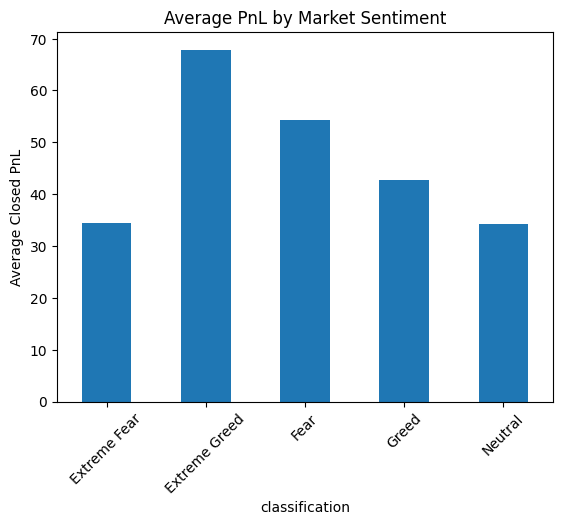

In [43]:
import matplotlib.pyplot as plt

# Average PnL by Sentiment
merged_data.groupby('classification')['Closed PnL'].mean().plot(kind='bar')
plt.title("Average PnL by Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)
plt.show()

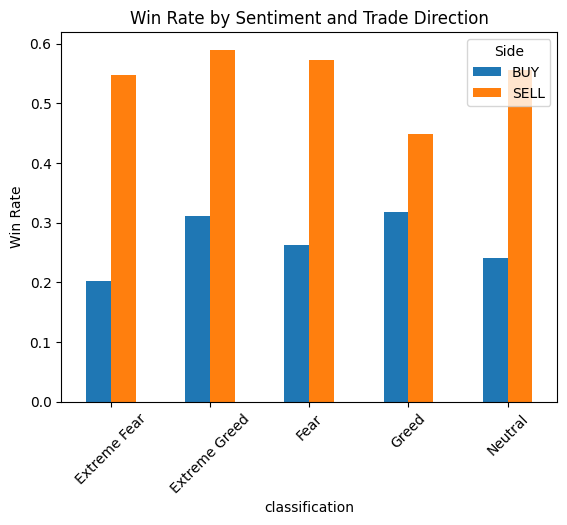

In [44]:
# Win Rate by Sentiment and Side
win_rates = merged_data.groupby(['classification', 'Side'])['is_profit'].mean().unstack()

win_rates.plot(kind='bar')
plt.title("Win Rate by Sentiment and Trade Direction")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)
plt.show()